In [ ]:
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

100%|██████████| 170M/170M [00:04<00:00, 39.0MB/s]


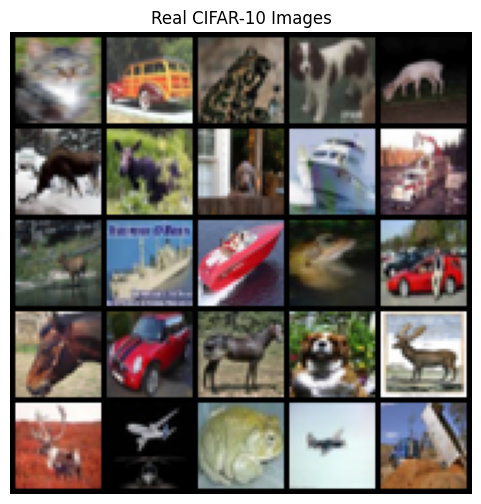

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

batch_size = 64

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, transform=transform, download=True
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

# Show real images
def show_real_images(loader):
    dataiter = iter(loader)
    images, _ = next(dataiter)
    images = images[:25]

    grid = torchvision.utils.make_grid(images, nrow=5, normalize=True)
    plt.figure(figsize=(6,6))
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.title("Real CIFAR-10 Images")
    plt.axis('off')
    plt.show()

show_real_images(train_loader)

In [ ]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, 4, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 4, 1, 0)
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

z_dim = 100
gen = Generator(z_dim).to(device)
critic = Critic().to(device)

opt_gen = optim.Adam(gen.parameters(), lr=1e-4, betas=(0.0, 0.9))
opt_critic = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.0, 0.9))


def gradient_penalty(critic, real, fake):
    batch_size, C, H, W = real.shape
    epsilon = torch.rand((batch_size, 1, 1, 1)).repeat(1, C, H, W).to(device)

    interpolated = real * epsilon + fake * (1 - epsilon)
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated)

    gradient = torch.autograd.grad(
        inputs=interpolated,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True
    )[0]

    gradient = gradient.view(gradient.shape[0], -1)
    gp = torch.mean((gradient.norm(2, dim=1) - 1) ** 2)

    return gp

In [ ]:
from IPython.display import clear_output

gen_losses = []
critic_losses = []

def show_generated_images(gen, z_dim):
    noise = torch.randn(64, z_dim, 1, 1).to(device)
    fake = gen(noise).detach().cpu()

    grid = torchvision.utils.make_grid(fake[:25], nrow=5, normalize=True)
    plt.figure(figsize=(5,5))
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.title("Generated Images")
    plt.axis('off')
    plt.show()


def plot_losses(gen_losses, critic_losses):
    plt.figure(figsize=(6,4))
    plt.plot(gen_losses, label="Generator Loss")
    plt.plot(critic_losses, label="Critic Loss")
    plt.legend()
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

Epoch [20/20]
Generator Loss: 23222.9453
Critic Loss: -5.3939


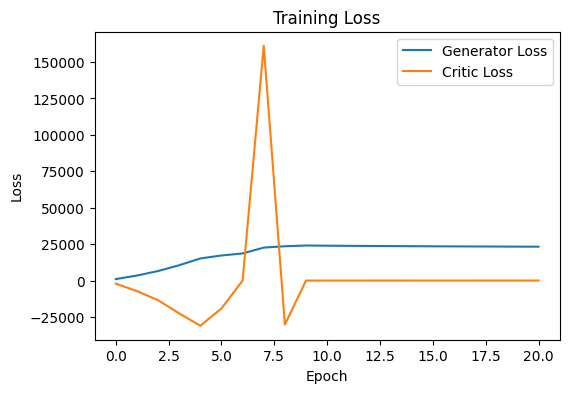

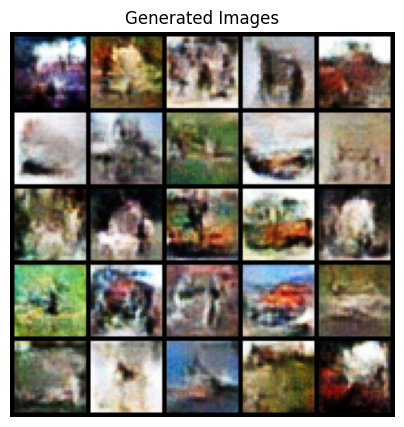

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
epochs = 20
lambda_gp = 10
critic_iterations = 5

best_loss = float('inf')   # for best model saving

for epoch in range(epochs):
    for batch_idx, (real, _) in enumerate(train_loader):
        real = real.to(device)
        cur_batch_size = real.shape[0]

        # ---- Train Critic ----
        for _ in range(critic_iterations):
            noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)
            fake = gen(noise)

            critic_real = critic(real)
            critic_fake = critic(fake.detach())

            gp = gradient_penalty(critic, real, fake)

            loss_critic = -(torch.mean(critic_real) - torch.mean(critic_fake)) + lambda_gp * gp

            opt_critic.zero_grad()
            loss_critic.backward()
            opt_critic.step()

        # ---- Train Generator ----
        noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)
        gen_fake = critic(fake)

        loss_gen = -torch.mean(gen_fake)

        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

    # Save losses
    gen_losses.append(loss_gen.item())
    critic_losses.append(loss_critic.item())


    # ⭐ SAVE BEST MODEL
    current_loss = loss_gen.item()

    if current_loss < best_loss and epoch > 2:
        best_loss = current_loss
        torch.save(gen.state_dict(), "best_generator.pth")
        print("✅ Best generator saved!")

    # 🔄 LIVE OUTPUT
    clear_output(wait=True)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Generator Loss: {loss_gen:.4f}")
    print(f"Critic Loss: {loss_critic:.4f}")

    plot_losses(gen_losses, critic_losses)
    show_generated_images(gen, z_dim)

# ===============================
# 8. DOWNLOAD BEST MODEL
# ===============================
from google.colab import files
files.download("best_generator.pth")